# Instalação das bibliotecas



In [1]:
!pip install optuna

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import optuna  # Para otimização de hiperparâmetros
from sklearn.metrics import root_mean_squared_error  # Para calcular o erro quadrático médio
from sklearn.metrics import mean_absolute_error
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import pickle
import random, os

Fazer o upload do arquivo disponibilizado:
> base_de_dados_etanol.csv



In [3]:
from google.colab import files
uploaded = files.upload()

# Transformação dos dados

In [4]:
df = pd.read_csv('base_de_dados_etanol.csv', encoding='latin-1', sep=';')
df['À vista R$'] = df['À vista R$'].str.replace(',', '.').astype(float)
df['Data'] = pd.to_datetime(df['Data'], format='%m/%Y')
df = df.sort_values('Data')
data = df['À vista R$'].values

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.reshape(-1,1)).flatten()


# Modelagem LSTM

In [5]:
# Função set_seed: A seed é como “fixar o ponto de partida da aleatoriedade”.
def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [6]:
# É utilizada para preparar dados de séries temporais para o modelo, criando sequências de entrada e saída. Com time_steps → tamanho da janela de entrada (quantos passos no passado) e horizon → quantos passos no futuro prevê.
def create_multistep_sequences(data, time_steps=12, horizon=24):
    X, y = [], []
    for i in range(len(data) - time_steps - horizon + 1):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps:i+time_steps+horizon])
    return np.array(X), np.array(y)

# É utilizada para preparar os dados para treinamento em modelos de deep learning, organizando-os em batches (lotes).
def get_loaders(X, y, batch_size):
    X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    dataset = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=False)


In [7]:
# Instanciando a previsão LSTM.
class LSTMForecast(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout, horizon):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            dropout=dropout if num_layers > 1 else 0.0, batch_first=True)
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


Rodando OPTUNA - Otimização dos Hiperparâmetros

In [8]:
#Criando a função para encontrar os melhores pontos.
def objective(trial):

    set_seed(42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Hiperparâmetros
    time_steps = trial.suggest_int("time_steps", 8, 24)
    hidden_size = trial.suggest_int("hidden_size", 16, 64)
    num_layers = trial.suggest_int("num_layers", 1, 2)
    dropout = trial.suggest_float("dropout", 0.0, 0.3)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])

    # Define-se aqui o quanto se quer prever, no caso utilizou-se 24 meses á frente.
    horizon = 24

    # Split correto
    split_idx = int(len(data_scaled) * 0.8)
    train_data = data_scaled[:split_idx]

    # Criar sequências
    X, y = create_multistep_sequences(train_data, time_steps, horizon)

    if len(X) == 0:
        return float("inf"), float("inf")

    # Validação
    val_size = int(0.2 * len(X))
    train_size = len(X) - val_size

    X_tr, X_val = X[:train_size], X[train_size:]
    y_tr, y_val = y[:train_size], y[train_size:]

    train_loader = get_loaders(X_tr, y_tr, batch_size)

    # Modelo
    model = LSTMForecast(
        input_size=1,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        horizon=horizon
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Treino, com 20 épocas
    for epoch in range(20):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            pred = model(xb)
            loss = criterion(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Validação
    model.eval()
    with torch.no_grad():
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32).unsqueeze(-1).to(device)
        preds = model(X_val_tensor).cpu().numpy()

    # RMSE
    from sklearn.metrics import mean_squared_error
    rmse = np.sqrt(mean_squared_error(y_val.flatten(), preds.flatten()))

    # 🔹 Gap (estabilidade)
    # aqui usamos variação simples como segundo objetivo
    rmse_std = np.std(preds.flatten() - y_val.flatten())

    return rmse, rmse_std

In [11]:
# Cria e configura o estudo do Optuna para uma otimização multiobjetivo reprodutível.
study = optuna.create_study(directions=['minimize','minimize'], sampler=optuna.samplers.TPESampler(seed=42))

# Executa a otimização por 1000 tentativas para encontrar os melhores hiperparâmetros.
study.optimize(objective, n_trials=1000)

import pickle

# Salva o resultado completo da otimização em um arquivo para uso futuro.
with open(f"study_horizon24.pkl", "wb") as f:
    pickle.dump(study, f)

[I 2026-03-23 19:37:41,721] A new study created in memory with name: no-name-13bfff06-078d-488b-96a7-65e808e6e228
[I 2026-03-23 19:37:42,156] Trial 0 finished with values: [0.6454304984034653, 0.21702792061510387] and parameters: {'time_steps': 14, 'hidden_size': 62, 'num_layers': 2, 'dropout': 0.17959754525911098, 'lr': 0.0002051338263087451, 'batch_size': 32}.
[I 2026-03-23 19:37:42,499] Trial 1 finished with values: [0.461774101605067, 0.19377630715375269] and parameters: {'time_steps': 18, 'hidden_size': 50, 'num_layers': 1, 'dropout': 0.29097295564859826, 'lr': 0.004622589001020831, 'batch_size': 8}.
[I 2026-03-23 19:37:42,655] Trial 2 finished with values: [0.4738554002980861, 0.1956233417859146] and parameters: {'time_steps': 13, 'hidden_size': 41, 'num_layers': 1, 'dropout': 0.08736874205941257, 'lr': 0.0016738085788752138, 'batch_size': 32}.
[I 2026-03-23 19:37:42,947] Trial 3 finished with values: [0.4091304575147993, 0.19071365445184965] and parameters: {'time_steps': 15, 'h

# Geração do gráfico de dispersão de resultados de otimização de hiperparâmetros

---
**⚠️ AÇÃO NECESSÁRIA:**

1.  **Usando o mouse, explore o gráfico abaixo e anote o número do "trial"** que você julgou ser o melhor.
2.  **Substitua o número na variável trial** pelo número do trial que você escolheu.
3.  **Execute a célula.** O código irá pegar os hiperparâmetros do trial escolhido e defini-los para o próximo passo.
---
/ tons de vermelho → destacam os melhores trials.

In [27]:
# Carrega o estudo de otimização salvo anteriormente.
with open("study_horizon24.pkl", "rb") as f:
    study_horizon24 = pickle.load(f)

# Importa o módulo de visualização do Optuna.
import optuna.visualization as vis

# Gera um gráfico da fronteira de Pareto para analisar o trade-off entre os dois objetivos da otimização.
fig = vis.plot_pareto_front(study_horizon24, axis_order=[1, 0], target_names=["Validation RMSE", "Gap(Val - Test RMSE)"])

# Exibe o gráfico.
fig.show()

/tmp/ipykernel_10915/2408929688.py:9: FutureWarning:

`axis_order` has been deprecated in v3.0.0. This feature will be removed in v5.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0.



Escolhemos aqui o ponto número 783.

In [28]:
trial_num = 783

trial_obj = next(t for t in study.trials if t.number == trial_num)

print("horizon:", 24)
print("params:", trial_obj.params)
print("values:", trial_obj.values)

horizon: 24
params: {'time_steps': 16, 'hidden_size': 62, 'num_layers': 1, 'dropout': 0.14233026280787175, 'lr': 0.0002874604518353706, 'batch_size': 16}
values: [0.3811561303002509, 0.18277621672910285]


Em best_params, coloca-se os parâmetros que encontramos no ponto escolhido anteriormente.

In [29]:
# Parâmetros.
best_params = {
   'time_steps': 16, 'hidden_size': 62, 'num_layers': 1, 'dropout': 0.14233026280787175, 'lr': 0.0002874604518353706, 'batch_size': 16
}

time_steps = best_params["time_steps"]
horizon = 24

# Fazendo o corte nos dados para o treinamento
split_idx = int(len(data_scaled) * 0.8)
train_data = data_scaled[:split_idx]
test_data = data_scaled[split_idx:]

X_train, y_train = create_multistep_sequences(train_data, time_steps, horizon)
train_loader = get_loaders(X_train, y_train, best_params['batch_size'])


In [30]:
# Adicionado para salvar o modelo

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = LSTMForecast(1, best_params['hidden_size'], best_params['num_layers'], best_params['dropout'], horizon).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=best_params['lr'])

for epoch in range(30):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# --- Adicionado: Salva o modelo treinado e o scaler ---
MODELO_SALVO = "final_lstm_model_multistep_24.pkl"
with open(MODELO_SALVO, 'wb') as f:
    pickle.dump({
        'scaler': scaler,
        'time_steps': time_steps,
        'horizon': horizon,
        'params': best_params,
        'model_state_dict': model.state_dict()
    }, f)
print(f"Modelo e scaler salvos em {MODELO_SALVO}")
# --- Fim da adição ---


Modelo e scaler salvos em final_lstm_model_multistep_24.pkl


In [22]:
# --- Função de treinamento ---
def train_model(model, train_loader, criterion, optimizer, device, epochs=30):

    model.train()

    for epoch in range(epochs):

        for xb, yb in train_loader:

            xb = xb.to(device)
            yb = yb.to(device);

            pred = model(xb);

            loss = criterion(pred, yb);

            optimizer.zero_grad();

            loss.backward();

            optimizer.step();


# --- Rolling Forecast ---
def rolling_forecast_gpu(data_scaled, scaler, best_params, horizon, epochs=30):

    set_seed(130);

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu");

    rmse_janelas = [];
    previsoes_primeiro_ponto = [];
    indices_primeiros_pontos = [];

    # --- hiperparâmetros ---
    time_steps = best_params['time_steps'];
    batch_size = best_params['batch_size'];
    hidden_size = best_params['hidden_size'];
    num_layers = best_params['num_layers'];
    dropout = best_params['dropout'];
    lr = best_params['lr'];

    # --- cria sequências iniciais ---
    X, y = create_multistep_sequences(data_scaled, time_steps, horizon);

    if len(X) == 0:
        raise ValueError("Série temporal muito curta para os valores de time_steps e horizon");

    split_idx = int(len(X) * 0.8);

    X_train = X[:split_idx];

    initial_train_len = len(X_train) + time_steps + horizon - 1;

    dados_treino = data_scaled[:initial_train_len];

    # número de janelas
    n_janelas = len(data_scaled) - initial_train_len - horizon + 1;

    if n_janelas <= 0:
        raise ValueError("Não há dados suficientes para criar janelas de rolling forecast.");

    # --- loop rolling forecast ---
    for i in range(n_janelas):

        set_seed(130);

        X_train_local, y_train_local = create_multistep_sequences(
            dados_treino, time_steps, horizon
        );

        if len(X_train_local) == 0:
            break;

        train_loader = get_loaders(X_train_local, y_train_local, batch_size);

        # cria modelo novo
        model = LSTMForecast(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            horizon=horizon
        ).to(device);

        criterion = nn.MSELoss();

        optimizer = torch.optim.Adam(model.parameters(), lr=lr);

        # treino
        train_model(model, train_loader, criterion, optimizer, device, epochs);

        # entrada da previsão
        seq_input = dados_treino[-time_steps:];

        seq_input_tensor = torch.tensor(
            seq_input, dtype=torch.float32
        ).unsqueeze(0).unsqueeze(-1).to(device);

        model.eval();

        with torch.no_grad():

            pred_scaled = model(seq_input_tensor).cpu().numpy().flatten();

        pred = scaler.inverse_transform(
            pred_scaled.reshape(-1, 1)
        ).flatten();

        # janela de teste
        inicio_janela = initial_train_len + i;

        fim_janela = inicio_janela + horizon;

        janela_teste = data_scaled[inicio_janela:fim_janela];

        if len(janela_teste) < horizon:
            break;

        y_true = scaler.inverse_transform(
            janela_teste.reshape(-1, 1)
        ).flatten();

        # erro
        rmse = root_mean_squared_error(y_true, pred);

        rmse_janelas.append(rmse);

        previsoes_primeiro_ponto.append(pred[0]);

        indices_primeiros_pontos.append(inicio_janela);

        # atualiza dados de treino corretamente
        dados_treino = data_scaled[:inicio_janela + 1];

    # valores reais
    valores_reais_primeiros_pontos = scaler.inverse_transform(
        data_scaled[indices_primeiros_pontos].reshape(-1, 1)
    ).flatten();

    return rmse_janelas, previsoes_primeiro_ponto, valores_reais_primeiros_pontos

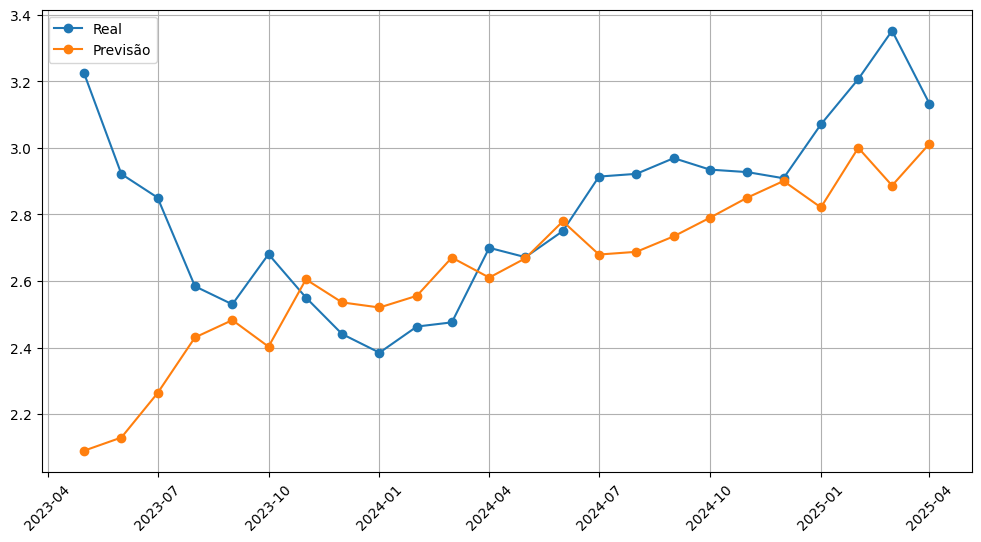

In [31]:
# Previsão
last_seq = train_data[-time_steps:]
last_seq_tensor = torch.tensor(last_seq, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)

model.eval()
with torch.no_grad():
    forecast_scaled = model(last_seq_tensor).cpu().numpy().flatten()

forecast = scaler.inverse_transform(forecast_scaled.reshape(-1,1)).flatten()

test_real = scaler.inverse_transform(test_data[:horizon].reshape(-1,1)).flatten()
datas_test = df['Data'].iloc[split_idx:split_idx+horizon]

min_len = min(len(datas_test), len(forecast))
datas_test = datas_test[:min_len]
test_real = test_real[:min_len]
forecast = forecast[:min_len]

plt.figure(figsize=(12,6))
plt.plot(datas_test, test_real, label='Real', marker='o')
plt.plot(datas_test, forecast, label='Previsão', marker='o')
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.show()


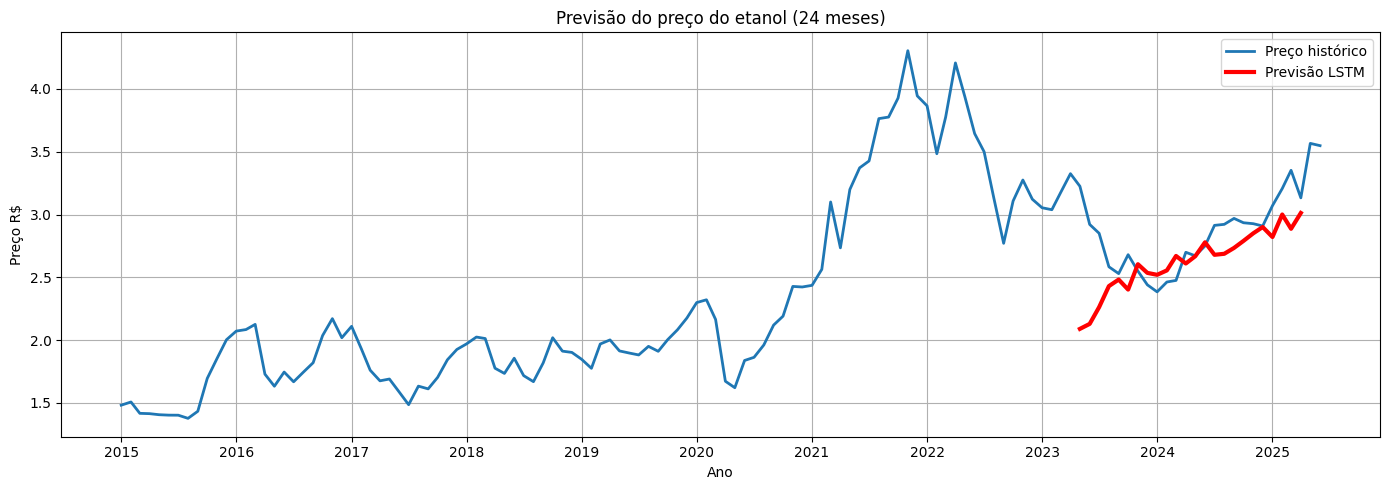

In [32]:
# --- Célula de Previsão ---
import matplotlib.dates as mdates

MODELO_SALVO = "final_lstm_model_multistep_24.pkl"

# Carregar dados do etanol
df = pd.read_csv("base_de_dados_etanol.csv", encoding='latin-1', sep=';')

df["À vista R$"] = df["À vista R$"].str.replace(",", ".").astype(float)
df["Data"] = pd.to_datetime(df["Data"], format="%m/%Y")

df = df.sort_values("Data")

data = df["À vista R$"].values


class LSTMForecast(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout, horizon):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            dropout=dropout if num_layers > 1 else 0.0, batch_first=True)
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


with open(MODELO_SALVO, "rb") as f:
    saved = pickle.load(f)

scaler = saved["scaler"]
time_steps = saved["time_steps"]
halogen = saved["horizon"]
best_params = saved["params"]

data_scaled = scaler.transform(data.reshape(-1, 1)).flatten()

data_scaled_train = data_scaled[:split_idx]
last_seq = data_scaled_train[-time_steps:]
last_seq_tensor = torch.tensor(last_seq, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)

final_model = LSTMForecast(
    input_size=1,
    hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"],
    dropout=best_params["dropout"],
    horizon=horizon
)

model.load_state_dict(saved["model_state_dict"])
model.eval()

with torch.no_grad():
    forecast_scaled = model(last_seq_tensor).numpy().flatten()

forecast = np.maximum(
    scaler.inverse_transform(forecast_scaled.reshape(-1, 1)).flatten(),
    0
)

# Datas para gráfico
datas_originais = df["Data"]
ultima_data_treino = df["Data"].iloc[split_idx - 1]

datas_previsao = df["Data"].iloc[split_idx:split_idx + halogen]

plt.figure(figsize=(14,5))

plt.plot(datas_originais, data, label="Preço histórico", linewidth=2)
plt.plot(datas_previsao, forecast, label="Previsão LSTM", linewidth=3, color='red')

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title(f"Previsão do preço do etanol ({halogen} meses)")
plt.xlabel("Ano")
plt.ylabel("Preço R$")
plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()

### Validar os Hiperparâmetros Escolhidos

---
**⚠️ AÇÃO NECESSÁRIA:**

1.  **Execute esta célula para avaliar a qualidade do ajuste.** Se o ajuste não estiver satisfatório, volte ao passo 3 e escolha novos hiperparâmetros.

**Atenção:** Esta validação também pode demorar. Ela irá testar o desempenho dos hiperparâmetros escolhidos e salva os resultados.

---


In [33]:
# Executa a função de rolling forecast com os hiperparâmetros definidos.
# O horizonte de previsão é de 24 meses e o modelo é treinado por 30 épocas em cada janela.
rmse_janelas24, previsoes_primeiro_ponto24, valores_reais_primeiros_pontos24 = rolling_forecast_gpu(
    data_scaled, scaler, best_params, horizon=12, epochs=30
)

# Agrupa os resultados em um dicionário para facilitar o salvamento.
rolling_forecast_results = {
    "rmse_janelas": rmse_janelas24,
    "previsoes_primeiro": previsoes_primeiro_ponto24,
    "reais_primeiro": valores_reais_primeiros_pontos24
}

# Salva o dicionário em um arquivo binário.
with open("rolling_forecast_results_h24.pkl", "wb") as f:
    pickle.dump(rolling_forecast_results, f)

print("\nExecução do Rolling Forecast concluída e resultados salvos em 'rolling_forecast_results_h24.pkl'")


Execução do Rolling Forecast concluída e resultados salvos em 'rolling_forecast_results_h24.pkl'


# Cálculo das métricas de **desempenho**

In [34]:
def mean_absolute_percentage_error(y_true, y_pred):
    # Evita divisão por zero
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100

results_filename = "rolling_forecast_results_h24.pkl"

if os.path.exists(results_filename):
    with open(results_filename, "rb") as f:
        rolling_forecast_results = pickle.load(f)

    previsoes_primeiro_ponto = rolling_forecast_results["previsoes_primeiro"]
    valores_reais_primeiros_pontos = rolling_forecast_results["reais_primeiro"]

    # Garante que as previsões não sejam negativas
    previsoes_primeiro_ponto = np.maximum(previsoes_primeiro_ponto, 0)

    # Calcula MAE
    mae_final = mean_absolute_error(valores_reais_primeiros_pontos, previsoes_primeiro_ponto)

    # Calcula MAPE
    mape_final = mean_absolute_percentage_error(valores_reais_primeiros_pontos, previsoes_primeiro_ponto)

    # Calcula sMAPE
    smape_final = symmetric_mean_absolute_percentage_error(valores_reais_primeiros_pontos, previsoes_primeiro_ponto)

    # O RMSE já foi calculado e impresso, podemos recuperá-lo se necessário ou recalcular
    rmse_final = np.sqrt(np.mean((valores_reais_primeiros_pontos - previsoes_primeiro_ponto)**2))

    # Exibe as métricas
    print("\nMétricas de Validação do Rolling Forecast (Primeiro Ponto por Janela):")
    print(f"MAE: {mae_final:.3f}")
    print(f"MAPE: {mape_final:.3f}%")
    print(f"RMSE: {rmse_final:.3f}")
    print(f"sMAPE: {smape_final:.3f}%")
else:
    print(f"Arquivo '{results_filename}' não encontrado. Por favor, execute o rolling forecast primeiro.")


Métricas de Validação do Rolling Forecast (Primeiro Ponto por Janela):
MAE: 0.140
MAPE: 5.316%
RMSE: 0.167
sMAPE: 5.371%
